In [74]:
#  core
import pandas as pd
import numpy as np
import joblib
import time
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import plotly.offline as py
# data preparation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
# data preprocessing
from sklearn.preprocessing import MinMaxScaler
# selection
from sklearn.model_selection import train_test_split, GridSearchCV
# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
# metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay, classification_report
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

Data Analysis Pepeline:
1. Data Exploration
2. Data Cleaning
3. EDA (Visualisation)
4. Feature Selection
5. Modeling
6. Model Evaluation & Optimization
7. Deployment & Interpretation

# **STEP 1: Data Exploration**

## **Column Descriptions**


🎯 Target Variable

| Column     | Description                                 |
|------------|---------------------------------------------|
| `id`       | Unique identifier (not useful for modeling) |
| `diagnosis`| Diagnosis result: **M = Malignant**, **B = Benign** |

---

📈 Mean Feature Columns

These are the mean values of various characteristics:

| Column                 | Description                                           |
|------------------------|-------------------------------------------------------|
| `radius_mean`          | Mean radius (distance from center to edge)            |
| `texture_mean`         | Mean texture (standard deviation of gray-scale values)|
| `perimeter_mean`       | Mean perimeter                                        |
| `area_mean`            | Mean area                                             |
| `smoothness_mean`      | Mean smoothness (local variation in radius lengths)   |
| `compactness_mean`     | Mean compactness (perimeter² / area - 1.0)            |
| `concavity_mean`       | Mean concavity (severity of concave portions)         |
| `concave points_mean`  | Mean number of concave portions of the contour        |
| `symmetry_mean`        | Mean symmetry                                         |
| `fractal_dimension_mean` | Mean fractal dimension ("coastline approximation")  |

---

📉 Standard Error Columns (`_se`)

These represent the standard error (variation) of each measurement:

| Column                 | Description                              |
|------------------------|------------------------------------------|
| `radius_se`            | Standard error of radius                 |
| `texture_se`           | Standard error of texture                |
| `perimeter_se`         | Standard error of perimeter              |
| `area_se`              | Standard error of area                   |
| `smoothness_se`        | Standard error of smoothness             |
| `compactness_se`       | Standard error of compactness            |
| `concavity_se`         | Standard error of concavity              |
| `concave points_se`    | Standard error of concave points         |
| `symmetry_se`          | Standard error of symmetry               |
| `fractal_dimension_se` | Standard error of fractal dimension      |

---

🔍 Worst Feature Columns (`_worst`)

These are the worst (largest) values recorded for each feature:

| Column                    | Description                                |
|---------------------------|--------------------------------------------|
| `radius_worst`            | Largest (worst) radius                     |
| `texture_worst`           | Largest texture                            |
| `perimeter_worst`         | Largest perimeter                          |
| `area_worst`              | Largest area                               |
| `smoothness_worst`        | Largest smoothness                         |
| `compactness_worst`       | Largest compactness                        |
| `concavity_worst`         | Largest concavity                          |
| `concave points_worst`    | Largest number of concave points           |
| `symmetry_worst`          | Largest symmetry                           |
| `fractal_dimension_worst` | Largest fractal dimension                  |


**Source:** https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

## **Descriptive Statistics**

In [4]:
# load the dataset
df = pd.read_csv("C:/Users/areza/Desktop/data.csv")

In [5]:
def dataset_snapshot(df):
    head = df.head(3)
    tail = df.tail(3)
    sample = df.sample(3)
    return pd.concat([head, tail, sample])

dataset_snapshot(df)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.26540,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.18600,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.24300,0.3613,0.08758,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039,NaN
523,917896,B,13.71,18.68,88.73,571.0,0.09916,0.10700,0.05385,0.03783,...,25.63,99.43,701.9,0.14250,0.25660,0.1935,0.12840,0.2849,0.09031,NaN
117,864729,M,14.87,16.67,98.64,682.5,0.11620,0.16490,0.16900,0.08923,...,27.37,127.10,1095.0,0.18780,0.44800,0.4704,0.20270,0.3585,0.10650,NaN
240,88350402,B,13.64,15.60,87.38,575.3,0.09423,0.06630,0.04705,0.03731,...,19.05,94.11,683.4,0.12780,0.12910,0.1533,0.09222,0.2530,0.06510,NaN


In [6]:
def quick_overview(df):
    return pd.DataFrame({
        "dtype": df.dtypes,
        "nunique": df.nunique(),
        "missing": df.isnull().sum()
    }).reset_index().rename(columns={"index": "column"})
quick_overview(df)

,column,dtype,nunique,missing
0,id,int64,569,0
1,diagnosis,object,2,0
2,radius_mean,float64,456,0
3,texture_mean,float64,479,0
4,perimeter_mean,float64,522,0
5,area_mean,float64,539,0
6,smoothness_mean,float64,474,0
7,compactness_mean,float64,537,0
8,concavity_mean,float64,537,0
9,concave points_mean,float64,542,0


In [7]:
def check_df(df, target=None, head=3):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 500)

    print("#################### SHAPE ########################")
    print(f"🔹 Rows: {df.shape[0]} | 🔹 Columns: {df.shape[1]}\n")
    
    print("#################### INFO #########################")
    print(df.info(), "\n")
 
    print("################## DESCRIPTIVE STATS (numerical) ##################")
    display(df.describe().T.style.background_gradient(cmap='PuBu'))
    
    print("################## DESCRIPTIVE STATS (categorical) ##################")
    display(df.describe(include='object').T.style.background_gradient(cmap='Oranges'))
    
    print("################## DUPLICATES ##################")
    print(f"🔁 Duplicate Rows: {df.duplicated().sum()}\n")

    if target and target in df.columns:
        print("############ TARGET DISTRIBUTION ############")
        print(df[target].value_counts(), "\n")

check_df(df, target= 'Tumor_Type')

#################### SHAPE ########################
🔹 Rows: 569 | 🔹 Columns: 33

#################### INFO #########################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  r

,count,mean,std,min,25%,50%,75%,max
id,569.000000,30371831.432337,125020585.612224,8670.000000,869218.000000,906024.000000,8813129.000000,911320502.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000


################## DESCRIPTIVE STATS (categorical) ##################


,count,unique,top,freq
diagnosis,569,2,B,357


################## DUPLICATES ##################
🔁 Duplicate Rows: 0



In [8]:
def show_unique_categories(df):
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        print(f"{col} ({df[col].nunique()} unique): {df[col].unique()[:5]}{'...' if df[col].nunique() > 5 else ''}")

show_unique_categories(df)

diagnosis (2 unique): ['M' 'B']


# **STEP 2: Data Cleaning**

In [9]:
# inspecting null values
missing_percentage = (df.isnull().sum() / len(df)) * 100
for col, perc in missing_percentage.items():
    print(f"{col}: {perc:.2f}%")

id: 0.00%
diagnosis: 0.00%
radius_mean: 0.00%
texture_mean: 0.00%
perimeter_mean: 0.00%
area_mean: 0.00%
smoothness_mean: 0.00%
compactness_mean: 0.00%
concavity_mean: 0.00%
concave points_mean: 0.00%
symmetry_mean: 0.00%
fractal_dimension_mean: 0.00%
radius_se: 0.00%
texture_se: 0.00%
perimeter_se: 0.00%
area_se: 0.00%
smoothness_se: 0.00%
compactness_se: 0.00%
concavity_se: 0.00%
concave points_se: 0.00%
symmetry_se: 0.00%
fractal_dimension_se: 0.00%
radius_worst: 0.00%
texture_worst: 0.00%
perimeter_worst: 0.00%
area_worst: 0.00%
smoothness_worst: 0.00%
compactness_worst: 0.00%
concavity_worst: 0.00%
concave points_worst: 0.00%
symmetry_worst: 0.00%
fractal_dimension_worst: 0.00%
Unnamed: 32: 100.00%


In [10]:
# let's check duplicated values 
df.duplicated().sum()

np.int64(0)

In [ ]:
list = ['Unnamed: 32','id']
data = df.drop(list,axis = 1)
print(data.shape)
data.head()

(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# **STEP 3: EDA**

In [19]:
# getting the number of unique values
print(data['diagnosis'].unique())
# getting the lable unique values
print(data['diagnosis'].value_counts())
# getting the label value count

['M' 'B']
diagnosis
B    357
M    212
Name: count, dtype: int64


In [20]:
# count number of obvs in each class
benign, malignant = data['diagnosis'].value_counts()
print('Number of cells labeled Benign: ', benign)
print('Number of cells labeled Malignant : ', malignant)
print('')
print('% of cells labeled Benign', round(benign / len(data) * 100, 2), '%')
print('% of cells labeled Malignant', round(malignant / len(data) * 100, 2), '%')

Number of cells labeled Benign:  357
Number of cells labeled Malignant :  212

% of cells labeled Benign 62.74 %
% of cells labeled Malignant 37.26 %


In [21]:
# Plotting the count
px.histogram(data, x='diagnosis', color="diagnosis", barmode='group')

In [29]:
# Get counts and labels
diagnosis_counts = data['diagnosis'].value_counts()
labels = diagnosis_counts.index.map({'B': 'Benign', 'M': 'Malignant'})
values = diagnosis_counts.values

trace = go.Pie(
    labels=labels,
    values=values,
    textfont=dict(size=15),
    opacity=0.8,
    marker=dict(colors=['lightskyblue', 'gold'], line=dict(color='#000000', width=1.5))
)

layout = dict(title='Distribution of Diagnosis Variable')
fig = dict(data=[trace], layout=layout)
py.iplot(fig)

In [30]:
features_mean = data.loc[:,'radius_mean':'fractal_dimension_mean']
features_se = data.loc[:,'radius_se':'fractal_dimension_se']
features_worst = data.loc[:,'radius_worst':'fractal_dimension_worst']

In [ ]:
# Map diagnosis to 0 and 1 if needed
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

<Axes: title={'center': 'Correlation of Mean Features with Diagnosis'}>

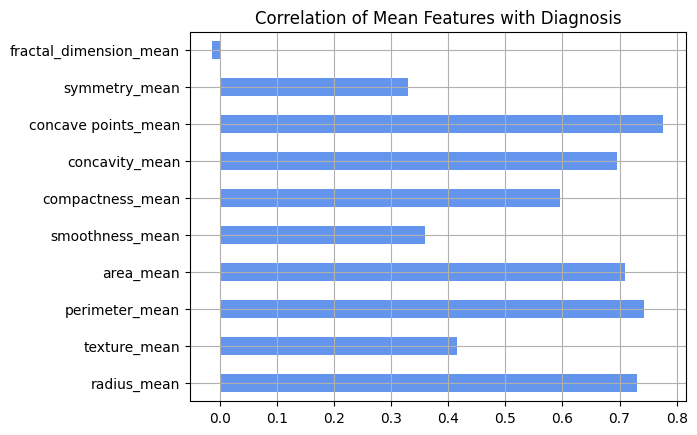

In [ ]:
# Plot correlation of mean features
features_mean.corrwith(data['diagnosis']).plot(
    kind='barh',
    grid=True,
    title="Correlation of Mean Features with Diagnosis",
    color="cornflowerblue"
)

<Axes: title={'center': 'Correlation of Mean Features with Diagnosis'}>

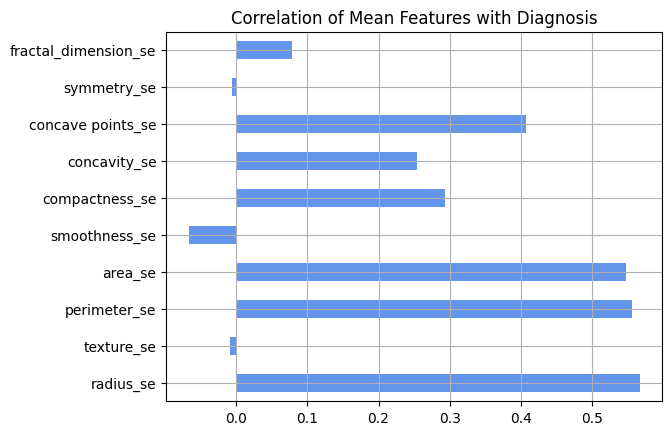

In [34]:
# Plot correlation of mean features
features_se.corrwith(data['diagnosis']).plot(
    kind='barh',
    grid=True,
    title="Correlation of Mean Features with Diagnosis",
    color="cornflowerblue"
)

<Axes: title={'center': 'Correlation of Mean Features with Diagnosis'}>

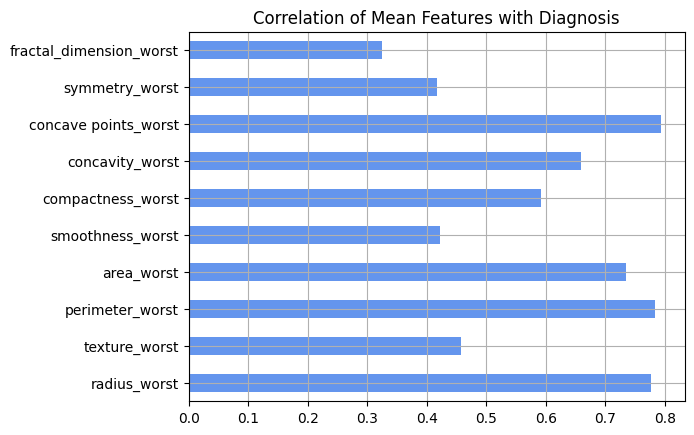

In [35]:
# Plot correlation of mean features
features_worst.corrwith(data['diagnosis']).plot(
    kind='barh',
    grid=True,
    title="Correlation of Mean Features with Diagnosis",
    color="cornflowerblue"
)

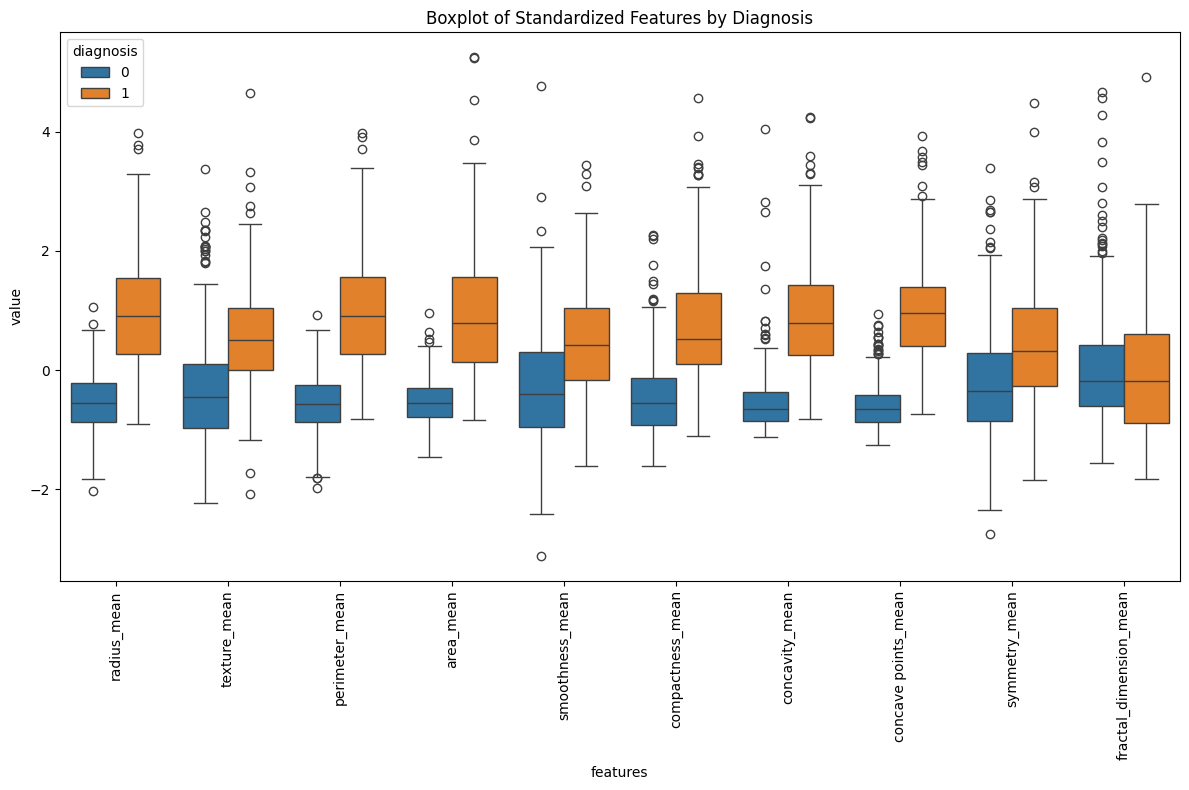

In [37]:
# Label and feature group selection
label = data['diagnosis']
outlier = features_mean  # Change this to features_se or features_worst if desired

# Standardize the feature values (Z-score scaling)
scaled_data = (outlier - outlier.mean()) / outlier.std()

# Merge standardized features with diagnosis label
merged_data = pd.concat([label, scaled_data], axis=1)

# Reshape for seaborn
fm = pd.melt(merged_data, id_vars="diagnosis", 
             var_name="features", value_name="value")

# Plot
plt.figure(figsize=(12, 8))
sns.boxplot(x="features", y="value", hue="diagnosis", data=fm)
plt.xticks(rotation=90)
plt.title("Boxplot of Standardized Features by Diagnosis")
plt.tight_layout()
plt.show()

In [38]:
# correlation map using plotly

def correlation_mat(df):
  correlation = df.corr()
  # tick labels
  matrix_cols = correlation.columns.tolist()
  # convert to array
  corr_array  = np.array(correlation)
  # Plotting
  trace = go.Heatmap(z = corr_array,
                   x = matrix_cols,
                   y = matrix_cols,
                   xgap = 2,
                   ygap = 2,
                   colorscale='Viridis',
                   text=corr_array.round(2),
                   texttemplate="%{text}",
                   colorbar   = dict() ,
                  )
  layout = go.Layout(dict(title = 'Correlation Matrix for variables',
                        autosize = False,
                        height  = 720,
                        width   = 800,
                        margin  = dict(r = 0 ,l = 210,
                                       t = 25,b = 210,
                                     ),
                        yaxis   = dict(tickfont = dict(size = 9)),
                        xaxis   = dict(tickfont = dict(size = 9)),
                       )
                  )
  fig = go.Figure(data = [trace],layout = layout)
  py.iplot(fig)

In [40]:
# correlation matrix for the subsets
correlation_mat(features_mean)
correlation_mat(features_se)
correlation_mat(features_worst)

In [45]:
def pairplot(dfp):
    label = data['diagnosis']
    df = dfp
    scaled_data = (df - df.mean()) / (df.std()) # standardization
    dfc = pd.concat([label,scaled_data],axis=1)
    name = str([x for x in globals() if globals()[x] is dfp][0])
    if name == 'features_mean':
        x = "Mean"
    elif name == 'features_se':
        x = "Squared Error"
    elif name == 'features_worst':
        x = "Worst"
    sns.pairplot(data=dfc, hue='diagnosis', palette='crest', corner=True).fig.suptitle('Pairplot for {} Featrues'.format(x), fontsize = 20)

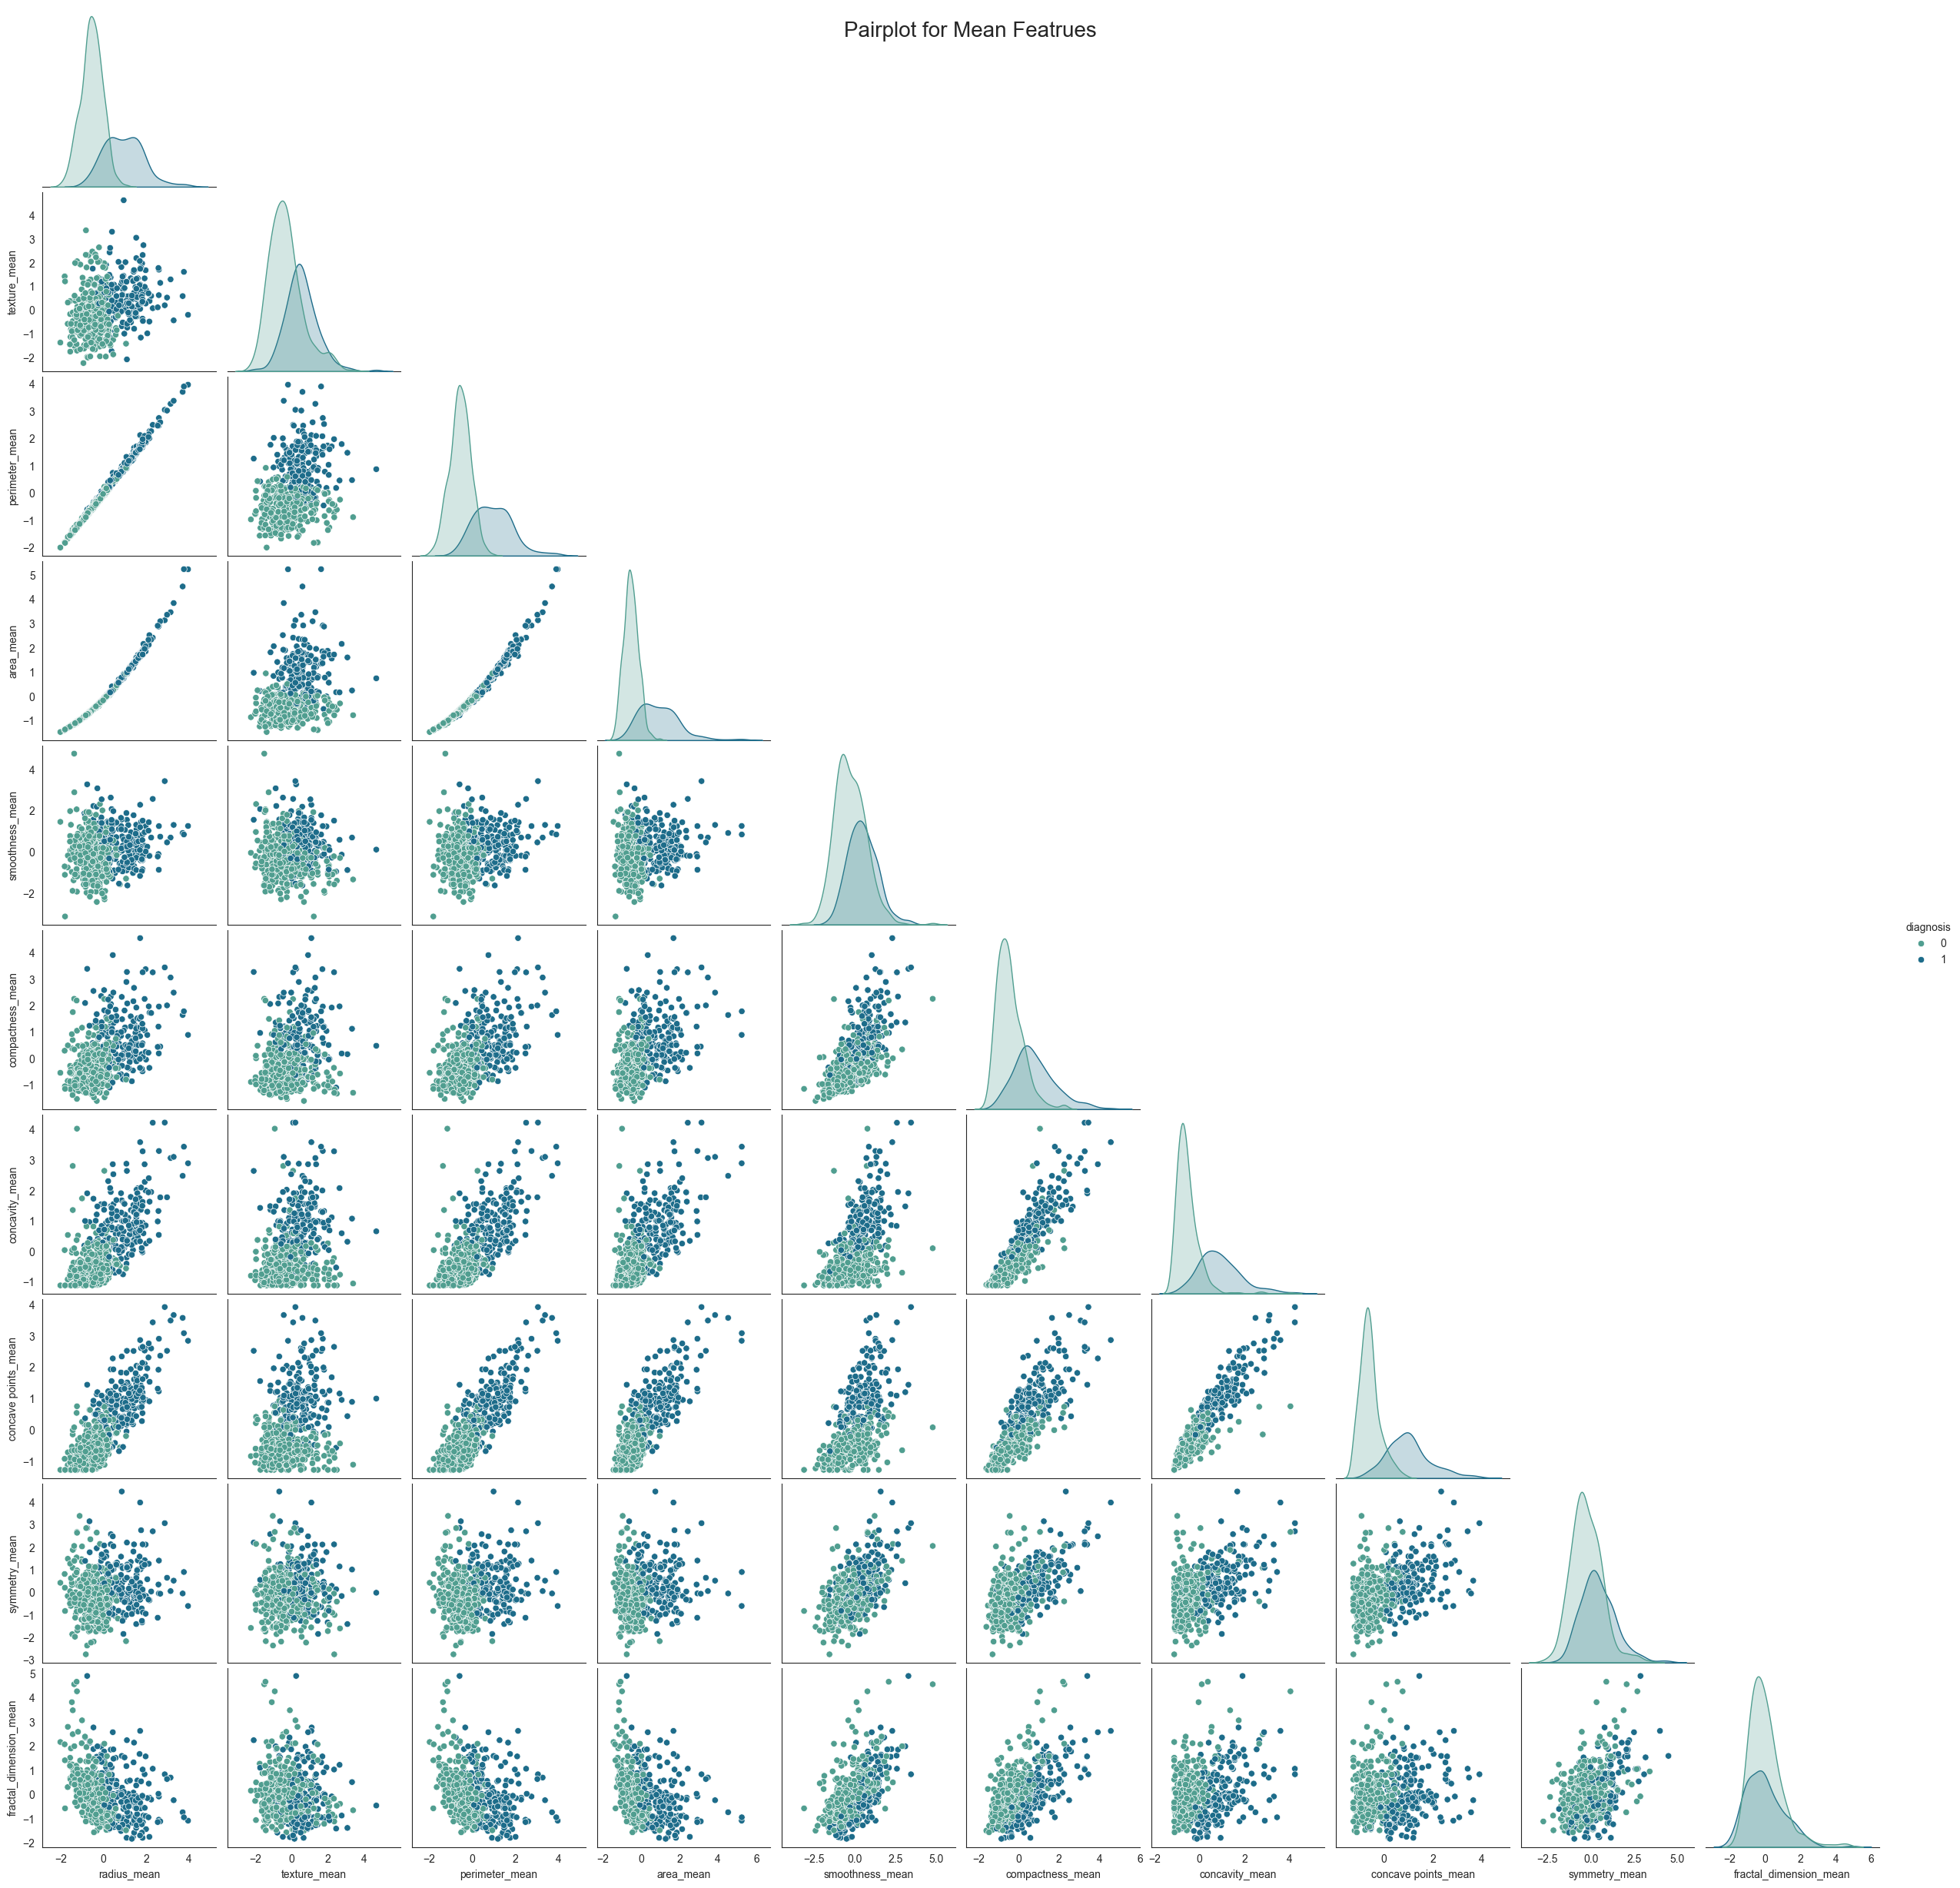

In [ ]:
pairplot(features_mean)
pairplot(features_se)
pairplot(features_worst)

In [47]:
def violin(df):
  label = data['diagnosis']
  df_mean = df
  scaled_data = (df_mean - df_mean.mean()) / (df_mean.std()) # standardization
  concat = pd.concat([label,scaled_data],axis=1)
  melt = pd.melt(concat,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
  plt.figure(figsize=(10,10))
  sns.violinplot(x="features", y="value", hue="diagnosis", data=melt,split=True, inner="quart")
  plt.xticks(rotation=90)

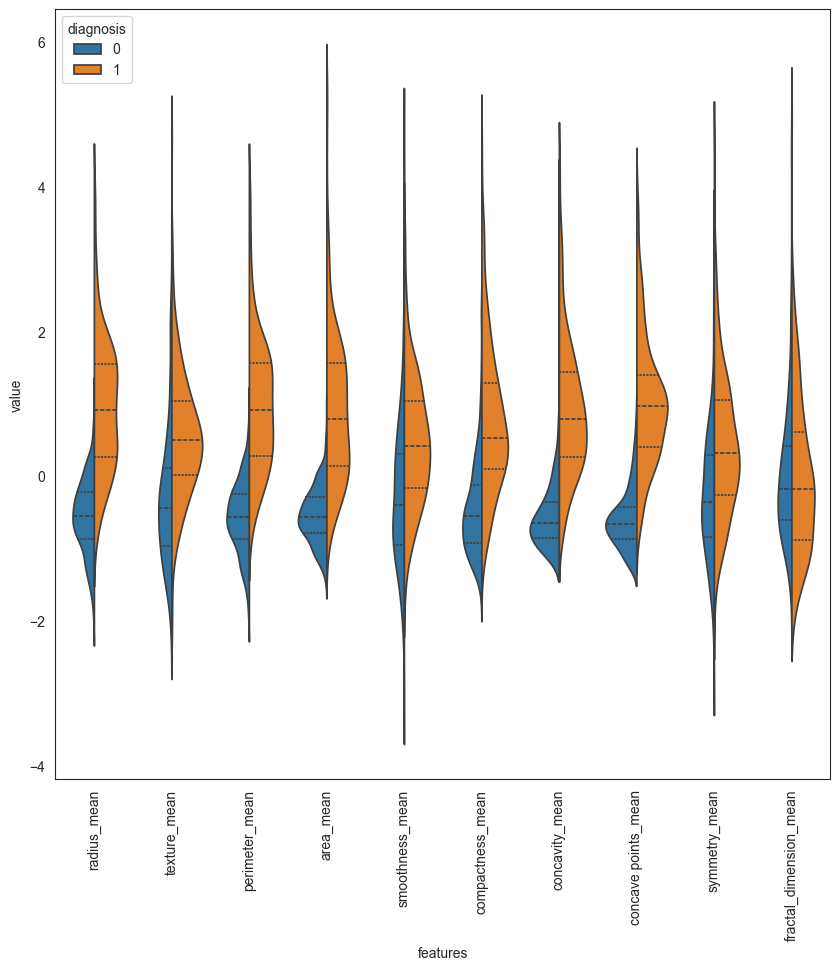

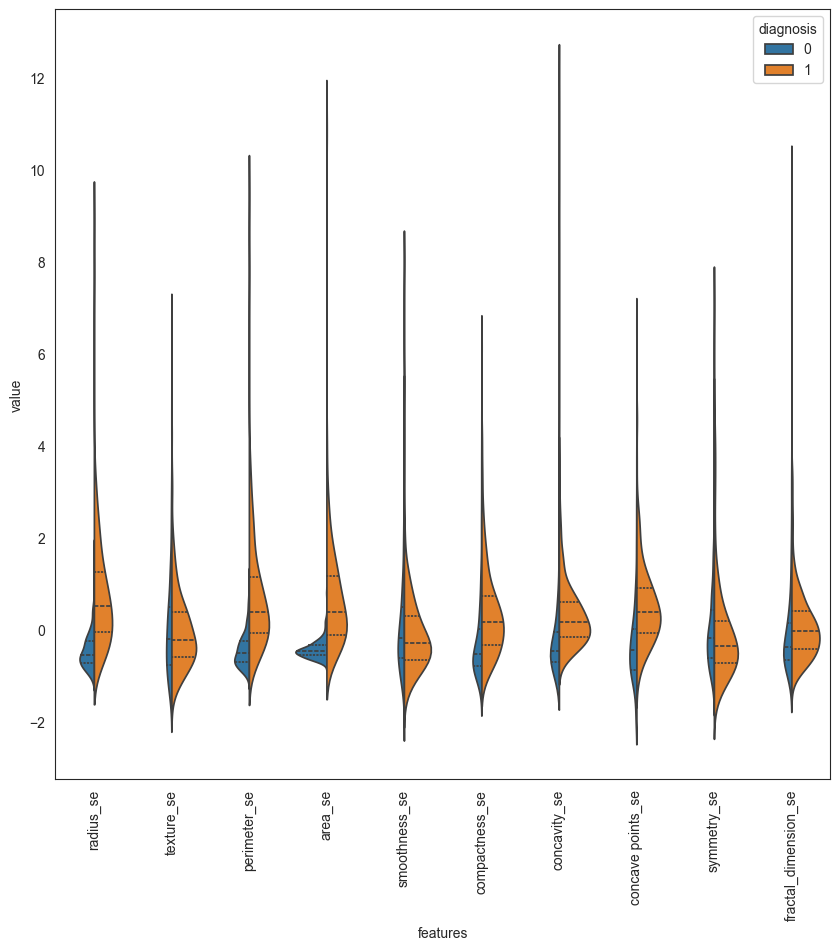

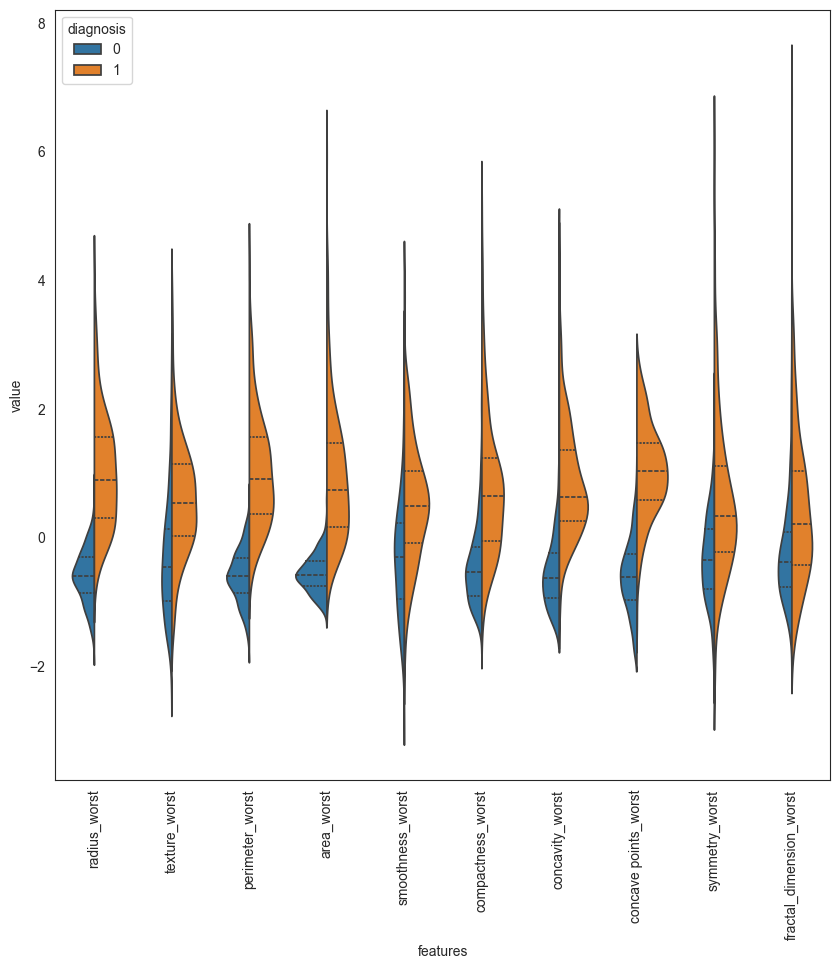

In [49]:
# first ten features
violin(features_mean)
violin(features_se)
violin(features_worst)

In [53]:
def swarm(df):
  sns.set(style="whitegrid", palette="muted")

  label = data['diagnosis']

  df_mean = df

  scaled_data = (df_mean - df_mean.mean()) / (df_mean.std()) # standardization
  concat = pd.concat([label,scaled_data],axis=1)
  melt = pd.melt(concat,id_vars="diagnosis",
                    var_name="features",
                    value_name='value')
  plt.figure(figsize=(10,10))
  tic = time.time()
  # sns.swarmplot(x="features", y="value", hue="diagnosis", data=melt)
  sns.stripplot(x="features", y="value", hue="diagnosis", data=melt)
  plt.xticks(rotation=90)

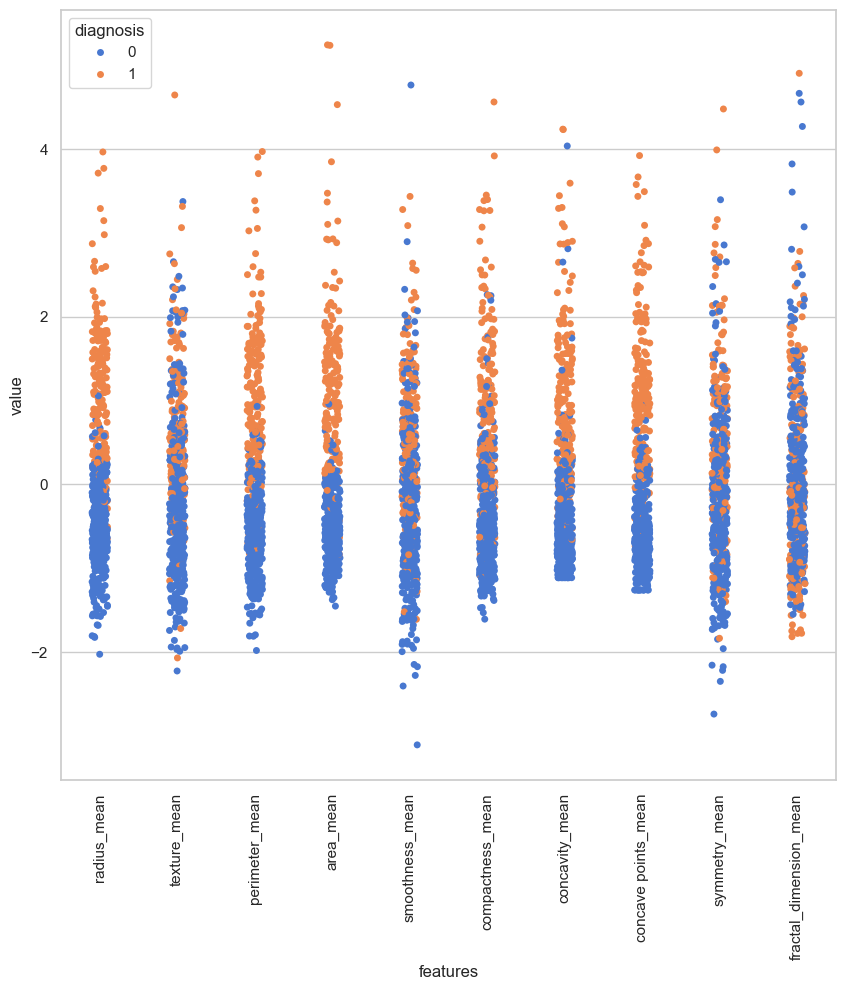

In [ ]:
# first ten features
swarm(features_mean)
swarm(features_se)
swarm(features_worst)

Accuracy is:  0.9649122807017544


<Axes: >

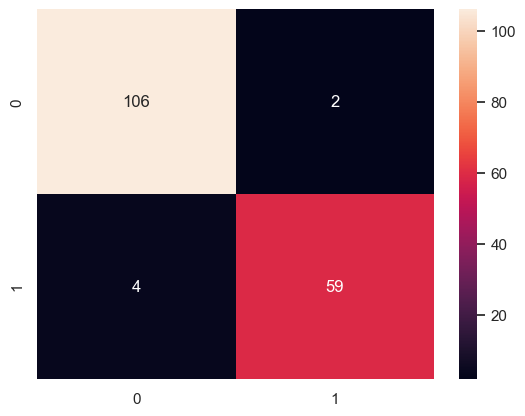

In [55]:
fsc = data.drop('diagnosis',axis = 1)

# split data train 70 % and test 30 %
X_train, X_test, y_train, y_test = train_test_split(fsc, data.diagnosis, test_size=0.3, random_state=42)

# random forest classifier with n_estimators=10 (default)
clf_rf = RandomForestClassifier(random_state=43)
clr_rf = clf_rf.fit(X_train,y_train)

ac = accuracy_score(y_test,clf_rf.predict(X_test))
print('Accuracy is: ',ac)
cm = confusion_matrix(y_test,clf_rf.predict(X_test))
sns.heatmap(cm,annot=True,fmt="d")

# **Step 4: Feature Selection**


In [61]:
# STEP 1: Separate features and target
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

# Remove Highly Correlated Features
corr_matrix = X.corr().abs()
# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find columns with correlation > 0.92
to_drop = [column for column in upper.columns if any(upper[column] > 0.92)]
print(f"Dropping {len(to_drop)} highly correlated features: {to_drop}")
# Drop them
X_filtered = X.drop(columns=to_drop)

Dropping 8 highly correlated features: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']


Top 10 important features:
concave points_worst      0.218666
radius_mean               0.159451
concavity_mean            0.123899
concavity_worst           0.101074
radius_se                 0.085596
compactness_worst         0.047673
compactness_mean          0.038836
texture_worst             0.028413
concavity_se              0.023659
fractal_dimension_mean    0.021091
dtype: float64


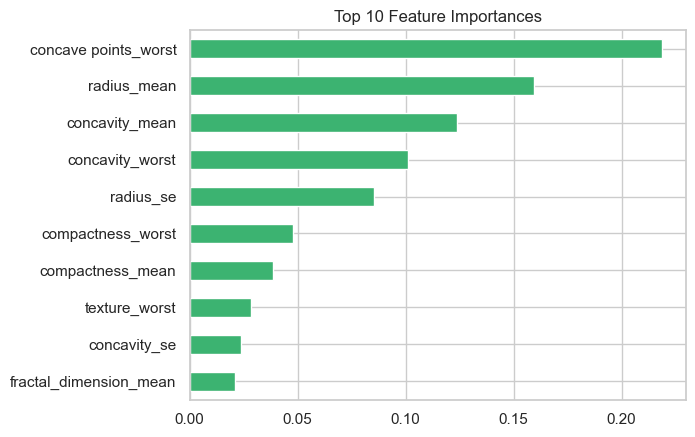

In [62]:
# Rank Feature Importance with Random Forest
# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_filtered, y)

# Get importance
importances = pd.Series(rf_model.feature_importances_, index=X_filtered.columns)
importances_sorted = importances.sort_values(ascending=False)

# Show top 10 features
print("Top 10 important features:")
print(importances_sorted.head(10))

# Plot
importances_sorted.head(10).plot(kind='barh', color='mediumseagreen', title='Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [65]:
# Keep top 10 only if you want a compact model
top_features = importances_sorted.head(10).index.tolist()
X_final = X_filtered[top_features]
X_final.columns.to_list()

['concave points_worst',
 'radius_mean',
 'concavity_mean',
 'concavity_worst',
 'radius_se',
 'compactness_worst',
 'compactness_mean',
 'texture_worst',
 'concavity_se',
 'fractal_dimension_mean']

# **STEP 5: Modeling**

In [115]:
X = data.drop('diagnosis',axis = 1)
y = data.diagnosis  # M or B

In [116]:
# Training Set (70%) → Used to train the model.
# Validation Set (15%) → Used to tune the model (hyperparameters).
# Test Set (15%) → Used to evaluate the final model performance.

# Split into Train (70%), Validation (15%), and Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
# random_states ensures that every time we run the code, we get the same random split.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print('X_train: ', np.shape(X_train))
print('y_train: ', np.shape(y_train))
print('X_test: ', np.shape(X_test))
print('y_test: ', np.shape(y_test))

X_train:  (398, 30)
y_train:  (398,)
X_test:  (86, 30)
y_test:  (86,)


In [117]:
# to avoid data leakage and ensure that our model generalizes well.
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [118]:
# training with different models

# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=30, max_features="sqrt", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate all models
model_summaries = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = round(accuracy_score(y_test, y_pred),4)
    cm = confusion_matrix(y_test, y_pred)
    f1 = round(f1_score(y_test, y_pred), 4)
    summary = {
    "Model" : name,
    "Accuracy" : accuracy,
    "F1 Score": f1,
    "Confusion Matrix": f"{cm.tolist()}"
    }
    
    model_summaries.append(summary)

results_df = pd.DataFrame(model_summaries)
results_df.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy,F1 Score,Confusion Matrix
5,SVM (Linear Kernel),1.0000,1.0000,"[[60, 0], [0, 26]]"
6,KNN,0.9884,0.9804,"[[60, 0], [1, 25]]"
1,Random Forest,0.9767,0.9600,"[[60, 0], [2, 24]]"
4,AdaBoost,0.9767,0.9615,"[[59, 1], [1, 25]]"
0,Logistic Regression,0.9651,0.9388,"[[60, 0], [3, 23]]"
3,Gradient Boosting,0.9535,0.9231,"[[58, 2], [2, 24]]"
2,Decision Tree,0.9419,0.9057,"[[57, 3], [2, 24]]"


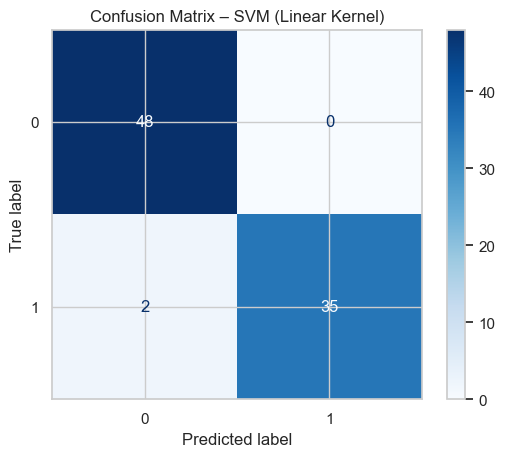


Classification Report for SVM (Linear Kernel)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        48
           1       1.00      0.95      0.97        37

    accuracy                           0.98        85
   macro avg       0.98      0.97      0.98        85
weighted avg       0.98      0.98      0.98        85



In [119]:
# Find the best model based on F1 Score
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

# Make predictions
y_pred = best_model.predict(X_val_scaled)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues')
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()

# Print classification report
print(f"\nClassification Report for {best_model_name}")
print(classification_report(y_val, y_pred))

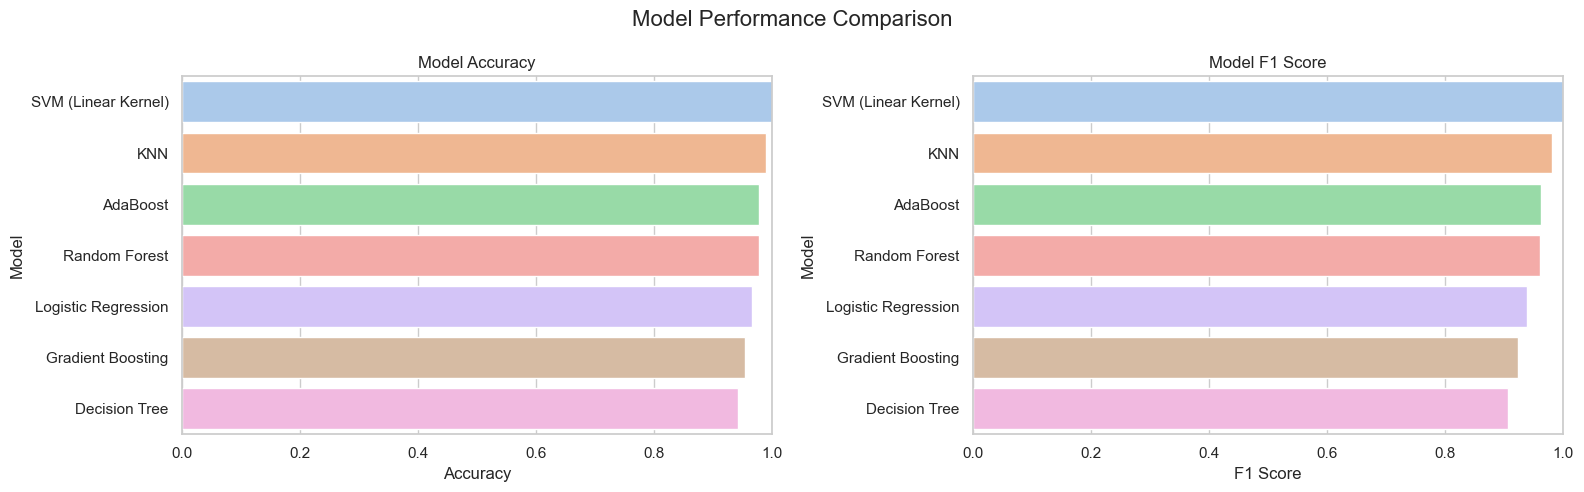

In [120]:
# Sort by F1 Score (or Accuracy if you want)
classification_df_sorted = results_df.sort_values(by="F1 Score", ascending=False)  # Ascending so best model is at top (barplot is horizontal)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy plot
sns.barplot(
    y='Model', x='Accuracy',
    data=classification_df_sorted,
    order=classification_df_sorted['Model'],
    palette='pastel',
    ax=axes[0]
)
axes[0].set_title("Model Accuracy")
axes[0].set_xlim(0, 1)

# F1 Score plot
sns.barplot(
    y='Model', x='F1 Score',
    data=classification_df_sorted,
    order=classification_df_sorted['Model'],
    palette='pastel',
    ax=axes[1]
)
axes[1].set_title("Model F1 Score")
axes[1].set_xlim(0, 1)

plt.suptitle("Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()


# **STEP 6: Model Evaluation**

In [121]:
# Define models and their hyperparameter grids
models_grid = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=9),
        'param_grid': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs'],
        }
    },
    'KNeighborsClassifier': {
        'model': KNeighborsClassifier(),
        'param_grid': {
            'n_neighbors': [3, 5, 7],
        }
    },
    'SVC': {
        'model': SVC(probability=True),
        'param_grid': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
        }
    },
    'DecisionTreeClassifier': {
        'model': DecisionTreeClassifier(),
        'param_grid': {
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(),
        'param_grid': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
        }
    },
    'GradientBoostingClassifier': {
        'model': GradientBoostingClassifier(),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 4],
        }
    },
    'XGBClassifier': {
        'model': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 4],
        }
    }
}

# Train and evaluate models
summary_list = []

for name, model_info in models_grid.items():
    model = model_info['model']
    param_grid = model_info['param_grid']
    grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_
    best_model.fit(X_train_scaled, y_train)
    y_pred = best_model.predict(X_test_scaled)

    summary_list.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    })

# Create DataFrame and display
summary_df = pd.DataFrame(summary_list).sort_values(by='Accuracy', ascending=False)
summary_df

,Model,Best Params,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,"{'C': 10, 'solver': 'lbfgs'}",0.9884,0.9630,1.0000,0.9811
1,KNeighborsClassifier,{'n_neighbors': 3},0.9884,1.0000,0.9615,0.9804
2,SVC,"{'C': 10, 'kernel': 'linear'}",0.9884,0.9630,1.0000,0.9811
4,RandomForestClassifier,"{'max_depth': 20, 'min_samples_leaf': 1, 'min_...",0.9767,1.0000,0.9231,0.9600
5,GradientBoostingClassifier,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9535,0.9231,0.9231,0.9231
3,DecisionTreeClassifier,"{'max_depth': 10, 'min_samples_leaf': 4, 'min_...",0.9419,0.9200,0.8846,0.9020
6,XGBClassifier,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9419,0.9200,0.8846,0.9020


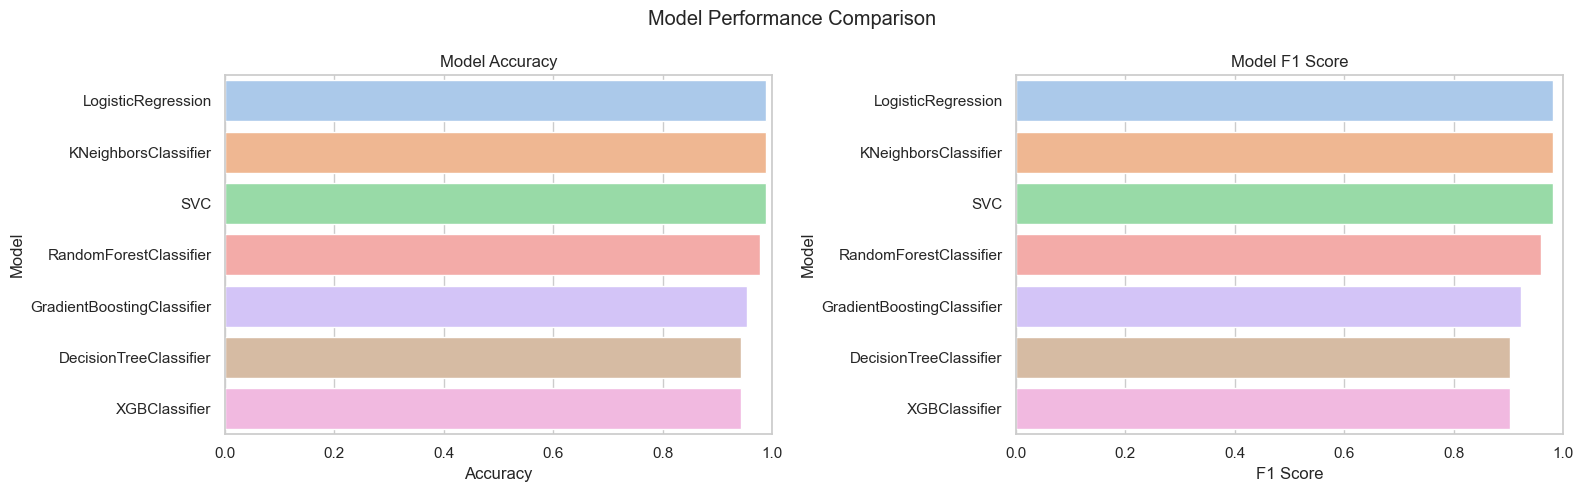

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(y=summary_df['Model'], x=summary_df['Accuracy'], palette='pastel', ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlim(0, 1)

sns.barplot(y=summary_df['Model'], x=summary_df['F1 Score'], palette='pastel', ax=axes[1])
axes[1].set_title("Model F1 Score")
axes[1].set_xlim(0, 1)

plt.suptitle("Model Performance Comparison")
plt.tight_layout()
plt.show()

# **Step 7: Deployment & Interpretation**

In [123]:
# Save the best model and scaler
joblib.dump(best_model, "breast_cancer_model.pkl")
joblib.dump(scaler, "scaler.pkl")  # Make sure to save the same scaler used before
print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!


In [124]:
# Load the saved model and scaler
loaded_model = joblib.load("breast_cancer_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Pick new patient samples from test set
new_patients = X_test.iloc[:5]

# Scale the input like during training
new_patients_scaled = loaded_scaler.transform(new_patients)

# Predict class and probabilities
predictions = loaded_model.predict(new_patients_scaled)
probabilities = loaded_model.predict_proba(new_patients_scaled)

# Display the results
for i in range(len(new_patients)):
    pred_class = "Malignant" if predictions[i] == 1 else "Benign"
    prob_benign = round(probabilities[i][0], 4)
    prob_malignant = round(probabilities[i][1], 4)

    print(f"🧪 Sample {i+1}")
    print(f"Prediction: {pred_class}")
    print(f"Probability (Benign, Malignant): ({prob_benign}, {prob_malignant})")
    print("-" * 40)


🧪 Sample 1
Prediction: Benign
Probability (Benign, Malignant): (0.9968000054359436, 0.0031999999191612005)
----------------------------------------
🧪 Sample 2
Prediction: Benign
Probability (Benign, Malignant): (0.9983000159263611, 0.0017000000225380063)
----------------------------------------
🧪 Sample 3
Prediction: Benign
Probability (Benign, Malignant): (0.9991000294685364, 0.0008999999845400453)
----------------------------------------
🧪 Sample 4
Prediction: Malignant
Probability (Benign, Malignant): (0.0013000000035390258, 0.9987000226974487)
----------------------------------------
🧪 Sample 5
Prediction: Benign
Probability (Benign, Malignant): (0.9878000020980835, 0.012199999764561653)
----------------------------------------
